Import necassary drives + packages

In [48]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.pipeline import Pipeline
data="/content/drive/MyDrive/Colab Notebooks/dataset/banknote.txt"

Mounted at /content/drive


Create 2-moons synthetic dataset using sklearn package.

Dataset created with 100000 instances.
       xpos      ypos  category
0 -1.090573  0.328829         0
1  1.401268  0.017229         1
2  0.810581  1.340124         0
3  1.529060 -0.585353         1
4  1.618489  0.006371         1


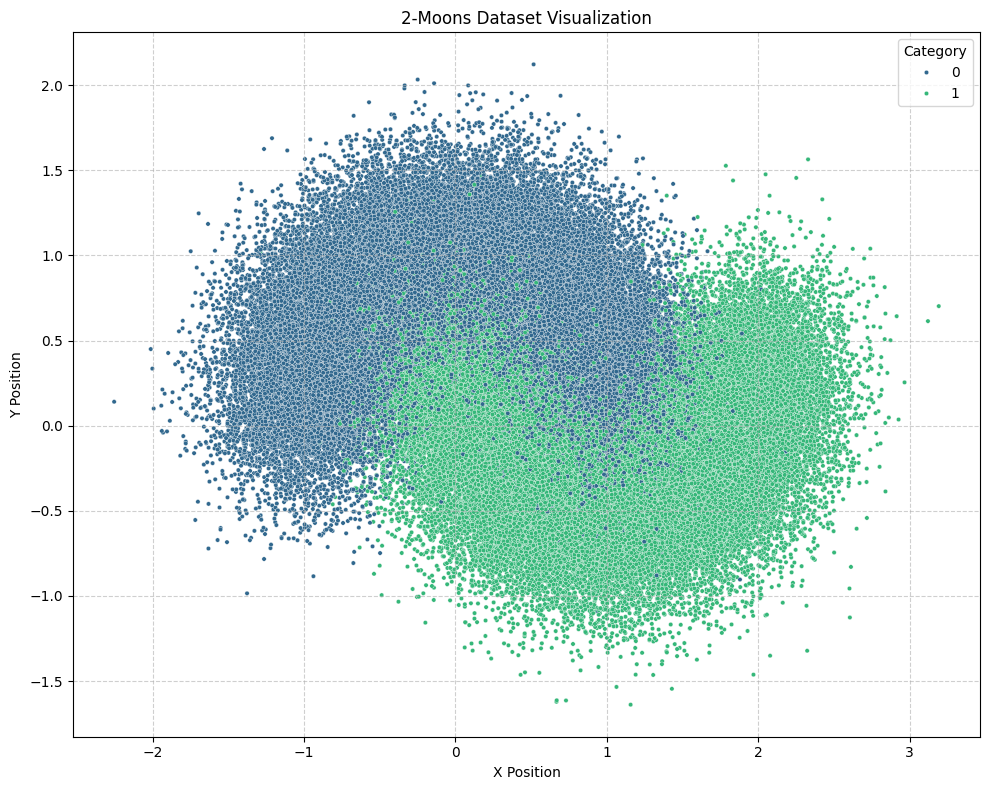

In [4]:
from sklearn.datasets import make_moons
Xm, ym = make_moons(n_samples=100000, noise=0.3, random_state=1)

# Convert to DataFrame for easier handling and consistency
data = pd.DataFrame(Xm, columns=['xpos', 'ypos'])
data['category'] = ym

print(f"Dataset created with {len(data)} instances.")
print(data.head())

#Graph

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=data, x='xpos', y='ypos', hue='category', palette='viridis', s=10, ax=ax)
plt.title('2-Moons Dataset Visualization')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

Use a pipelined linear logisitic regression model to fit the data. Then create a decision boundary graphic to visualize model effectiveness.

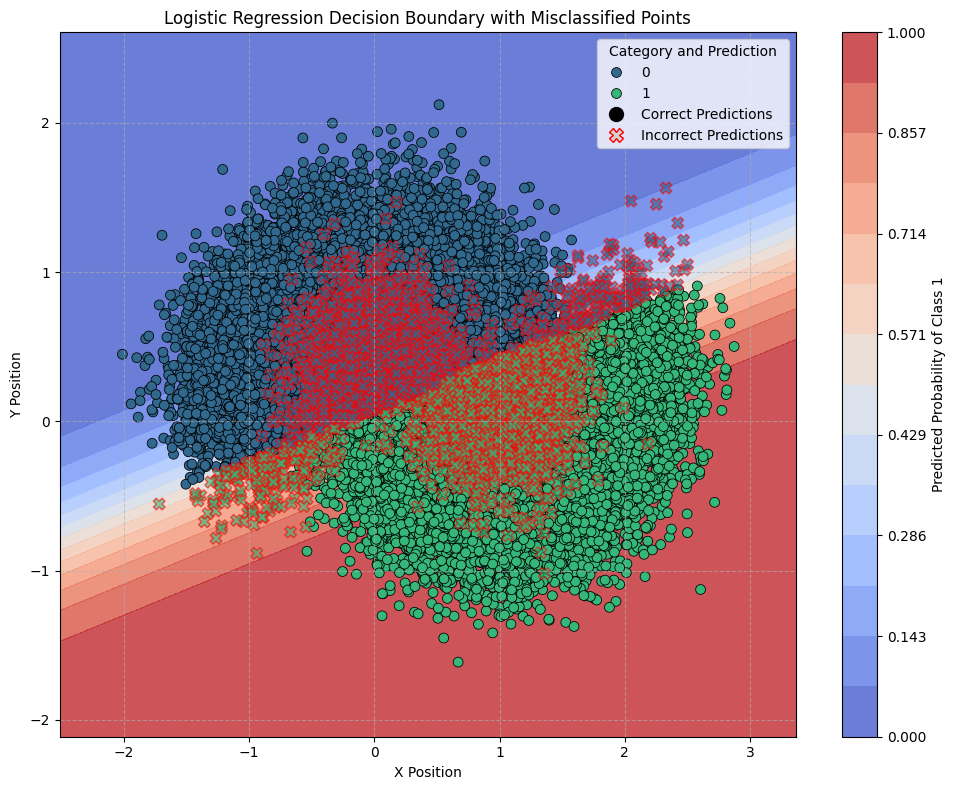

In [6]:
preprocessor_m = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['xpos', 'ypos'])
    ])

# Assuming 'data' DataFrame is available from previous cells
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(Xm, ym, test_size=0.3, random_state=1)
# Convert X_train_m and X_test_m to DataFrames for ColumnTransformer
X_train_m = pd.DataFrame(X_train_m, columns=['xpos', 'ypos'])
X_test_m = pd.DataFrame(X_test_m, columns=['xpos', 'ypos'])

# Create a pipeline with the preprocessor and LogisticRegression
log_reg_pipeline_m = Pipeline(steps=[('preprocessor', preprocessor_m),
                                   ('classifier', LogisticRegression(random_state=1))])

# Train the model
log_reg_pipeline_m.fit(X_train_m, y_train_m)

# Make predictions
y_pred_m = log_reg_pipeline_m.predict(X_test_m)
y_pred_proba_m = log_reg_pipeline_m.predict_proba(X_test_m)[:, 1]

#Graph

x_min, x_max = X_test_m['xpos'].min() - 0.5, X_test_m['xpos'].max() + 0.5
y_min, y_max = X_test_m['ypos'].min() - 0.5, X_test_m['ypos'].max() + 0.5

# Create a meshgrid to plot decision boundary
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict probabilities for each point in the meshgrid
# The preprocessor expects a DataFrame, so create one from xx and yy
meshgrid_data = pd.DataFrame({'xpos': xx.ravel(), 'ypos': yy.ravel()})
Z = log_reg_pipeline_m.predict_proba(meshgrid_data)[:, 1]
Z = Z.reshape(xx.shape)

# Create the plot
plt.figure(figsize=(10, 8))

# Plot decision boundary as a contour map
plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm', levels=np.linspace(0, 1, 15))
plt.colorbar(label='Predicted Probability of Class 1')

# Identify correctly and incorrectly predicted instances
correct_predictions = X_test_m[y_pred_m == y_test_m]
incorrect_predictions = X_test_m[y_pred_m != y_test_m]

# Plot correctly predicted instances
sns.scatterplot(
    x=correct_predictions['xpos'],
    y=correct_predictions['ypos'],
    hue=y_test_m[y_pred_m == y_test_m],
    palette='viridis',
    legend='full', # Let seaborn create hue legend for categories 0 and 1
    ax=plt.gca(),
    s=50,
    edgecolor='k'
    # Removed label='Correct Predictions' to avoid conflict
)

# Plot incorrectly predicted instances in a lighter shade
sns.scatterplot(
    x=incorrect_predictions['xpos'],
    y=incorrect_predictions['ypos'],
    hue=y_test_m[y_pred_m != y_test_m],
    palette='viridis_r',
    legend=False, # Don't show legend for incorrect to avoid clutter
    ax=plt.gca(),
    s=70,
    marker='X',
    edgecolor='red',
    linewidth=1,
    alpha=0.6
    # Removed label='Incorrect Predictions' to avoid conflict
)

# Add title and labels
plt.title('Logistic Regression Decision Boundary with Misclassified Points')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid(True, linestyle='--', alpha=0.6)

# Create custom legend handles for prediction types
from matplotlib.lines import Line2D

# Get existing handles and labels (from the 'hue' in the first scatterplot)
handles, labels = plt.gca().get_legend_handles_labels()

# Create custom handles for the 'Correct' and 'Incorrect' prediction types
correct_pred_handle = Line2D([0], [0], marker='o', color='w', label='Correct Predictions',
                               markeredgecolor='k', markerfacecolor='k', markersize=10, lw=0)
incorrect_pred_handle = Line2D([0], [0], marker='X', color='w', label='Incorrect Predictions',
                               markeredgecolor='red', markerfacecolor='lightgrey', markersize=10, lw=0)

# Combine the hue legend entries with the custom prediction type entries
final_handles = handles + [correct_pred_handle, incorrect_pred_handle]
final_labels = labels + ['Correct Predictions', 'Incorrect Predictions']

plt.gca().legend(handles=final_handles, labels=final_labels, title='Category and Prediction')

plt.tight_layout()
plt.show()

Use quantitative data to find data effectiveness (metrics).

In [14]:
# Calculate metrics for the entire linear Logistic Regression model
precision_linear = precision_score(y_test_m, y_pred_m, pos_label=1)
recall_linear = recall_score(y_test_m, y_pred_m, pos_label=1)
f1_linear = f1_score(y_test_m, y_pred_m, pos_label=1)

print(f"Metrics for the entire Linear Logistic Regression Model:")
print(f"Precision (Class 1): {precision_linear:.4f}")
print(f"Recall (Class 1): {recall_linear:.4f}")
print(f"F1-Score (Class 1): {f1_linear:.4f}")

Metrics for the entire Linear Logistic Regression Model:
Precision (Class 1): 0.8470
Recall (Class 1): 0.8440
F1-Score (Class 1): 0.8455


Find metrics in innacurate area to demonstrate where a linear boundary has limitations.

Metrics for Class 1 within ROI (x: [-0.5, 0.5], y: [-0.5, 0.5]):
Precision (Class 1 in ROI): 0.9461
Recall (Class 1 in ROI): 0.6178
F1-Score (Class 1 in ROI): 0.7475
Average Precision (Class 1 in ROI): 0.9475


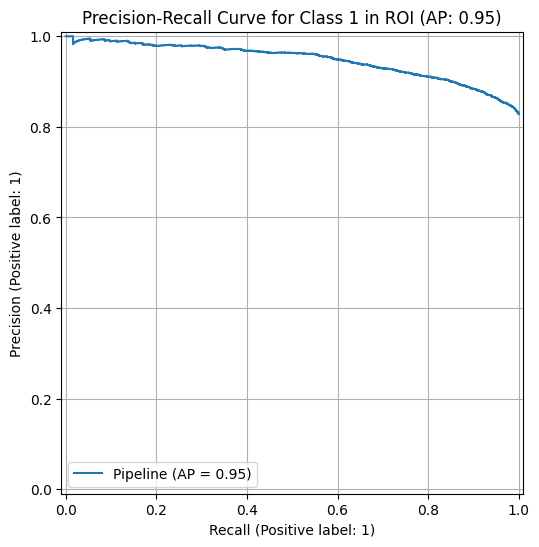

In [8]:
# Define the new region of interest
x_min_roi = -0.5
x_max_roi = 0.5
y_min_roi = -0.5
y_max_roi = 0.5

# Filter the test data for the region of interest
roi_mask = (X_test_m['xpos'] >= x_min_roi) & (X_test_m['xpos'] <= x_max_roi) & \
           (X_test_m['ypos'] >= y_min_roi) & (X_test_m['ypos'] <= y_max_roi)

X_roi = X_test_m[roi_mask]
y_roi = y_test_m[roi_mask]
y_pred_roi = log_reg_pipeline_m.predict(X_roi) # Predict for ROI using the pipeline
y_pred_proba_roi = log_reg_pipeline_m.predict_proba(X_roi)[:, 1] # Probabilities for Class 1

# Check if there are points in the region
if not X_roi.empty:
    print(f"Metrics for Class 1 within ROI (x: [{x_min_roi}, {x_max_roi}], y: [{y_min_roi}, {y_max_roi}]):")

    # Calculate precision, recall, f1-score for class 1
    # Ensure only class 1 predictions are considered or target_names if multiclass
    precision_class1_roi = precision_score(y_roi, y_pred_roi, pos_label=1)
    recall_class1_roi = recall_score(y_roi, y_pred_roi, pos_label=1)
    f1_class1_roi = f1_score(y_roi, y_pred_roi, pos_label=1)

    print(f"Precision (Class 1 in ROI): {precision_class1_roi:.4f}")
    print(f"Recall (Class 1 in ROI): {recall_class1_roi:.4f}")
    print(f"F1-Score (Class 1 in ROI): {f1_class1_roi:.4f}")

    # Calculate Average Precision (AP) score
    from sklearn.metrics import average_precision_score
    ap_score_roi = average_precision_score(y_roi, y_pred_proba_roi, pos_label=1)
    print(f"Average Precision (Class 1 in ROI): {ap_score_roi:.4f}")

    # Plot Precision-Recall Curve for Class 1 within ROI
    fig_pr_roi, ax_pr_roi = plt.subplots(figsize=(8, 6))
    PrecisionRecallDisplay.from_estimator(log_reg_pipeline_m, X_roi, y_roi, ax=ax_pr_roi, pos_label=1)
    ax_pr_roi.set_title(f'Precision-Recall Curve for Class 1 in ROI (AP: {ap_score_roi:.2f})')
    plt.grid(True)
    plt.show()

Create a polynomial logisitic regression model using sklearn package.

In [95]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=7)


X_poly_train = poly.fit_transform(X_train_m)
X_poly_test = poly.transform(X_test_m)

polymodel = LogisticRegression(random_state=1, max_iter=1000)
polymodel.fit(X_poly_train, y_train_m)

y_pred_poly = polymodel.predict(X_poly_test) # Predict on polynomial features of test data

Graph the new decision boundary.

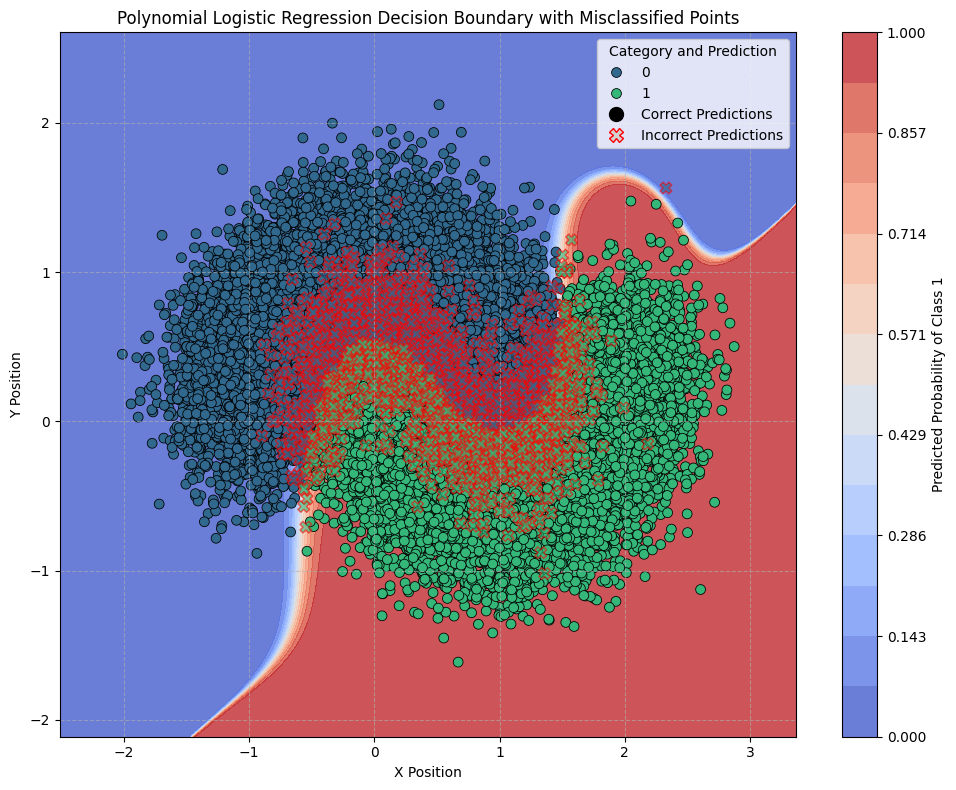

In [97]:
# Graph the decision boundary for the Polynomial Logistic Regression model

x_min_poly, x_max_poly = X_test_m['xpos'].min() - 0.5, X_test_m['xpos'].max() + 0.5
y_min_poly, y_max_poly = X_test_m['ypos'].min() - 0.5, X_test_m['ypos'].max() + 0.5

h_poly = 0.02  # step size in the mesh
xx_poly, yy_poly = np.meshgrid(np.arange(x_min_poly, x_max_poly, h_poly),
                                 np.arange(y_min_poly, y_max_poly, h_poly))

# Create a DataFrame from the meshgrid for transformation
meshgrid_data_poly = pd.DataFrame({'xpos': xx_poly.ravel(), 'ypos': yy_poly.ravel()})

# Transform meshgrid data using the fitted PolynomialFeatures
meshgrid_data_poly_transformed = poly.transform(meshgrid_data_poly)

# Predict probabilities for each point in the transformed meshgrid
Z_poly = polymodel.predict_proba(meshgrid_data_poly_transformed)[:, 1]
Z_poly = Z_poly.reshape(xx_poly.shape)

# Create the plot
plt.figure(figsize=(10, 8))

# Plot decision boundary as a contour map
plt.contourf(xx_poly, yy_poly, Z_poly, alpha=0.8, cmap='coolwarm', levels=np.linspace(0, 1, 15))
plt.colorbar(label='Predicted Probability of Class 1')

# Identify correctly and incorrectly predicted instances for the polynomial model
correct_predictions_poly = X_test_m[y_pred_poly == y_test_m]
incorrect_predictions_poly = X_test_m[y_pred_poly != y_test_m]

# Plot correctly predicted instances
sns.scatterplot(
    x=correct_predictions_poly['xpos'],
    y=correct_predictions_poly['ypos'],
    hue=y_test_m[y_pred_poly == y_test_m],
    palette='viridis',
    legend='full',
    ax=plt.gca(),
    s=50,
    edgecolor='k'
)

# Plot incorrectly predicted instances in a lighter shade
sns.scatterplot(
    x=incorrect_predictions_poly['xpos'],
    y=incorrect_predictions_poly['ypos'],
    hue=y_test_m[y_pred_poly != y_test_m],
    palette='viridis_r',
    legend=False,
    ax=plt.gca(),
    s=70,
    marker='X',
    edgecolor='red',
    linewidth=1,
    alpha=0.6
)

# Add title and labels
plt.title('Polynomial Logistic Regression Decision Boundary with Misclassified Points')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid(True, linestyle='--', alpha=0.6)

# Create custom legend handles for prediction types
from matplotlib.lines import Line2D

handles_poly, labels_poly = plt.gca().get_legend_handles_labels()

correct_pred_handle_poly = Line2D([0], [0], marker='o', color='w', label='Correct Predictions',
                                      markeredgecolor='k', markerfacecolor='k', markersize=10, lw=0)
incorrect_pred_handle_poly = Line2D([0], [0], marker='X', color='w', label='Incorrect Predictions',
                                        markeredgecolor='red', markerfacecolor='lightgrey', markersize=10, lw=0)

final_handles_poly = handles_poly + [correct_pred_handle_poly, incorrect_pred_handle_poly]
final_labels_poly = labels_poly + ['Correct Predictions', 'Incorrect Predictions']

plt.gca().legend(handles=final_handles_poly, labels=final_labels_poly, title='Category and Prediction')

plt.tight_layout()
plt.show()

Calculate the new metrics and metric visualizations of the model.

In [96]:
# Calculate metrics for the entire polynomial model
precision_poly = precision_score(y_test_m, y_pred_poly, pos_label=1)
recall_poly = recall_score(y_test_m, y_pred_poly, pos_label=1)
f1_poly = f1_score(y_test_m, y_pred_poly, pos_label=1)

print(f"Metrics for the entire Polynomial Logistic Regression Model:")
print(f"Precision (Class 1): {precision_poly:.4f}")
print(f"Recall (Class 1): {recall_poly:.4f}")
print(f"F1-Score (Class 1): {f1_poly:.4f}")

Metrics for the entire Polynomial Logistic Regression Model:
Precision (Class 1): 0.9138
Recall (Class 1): 0.9122
F1-Score (Class 1): 0.9130


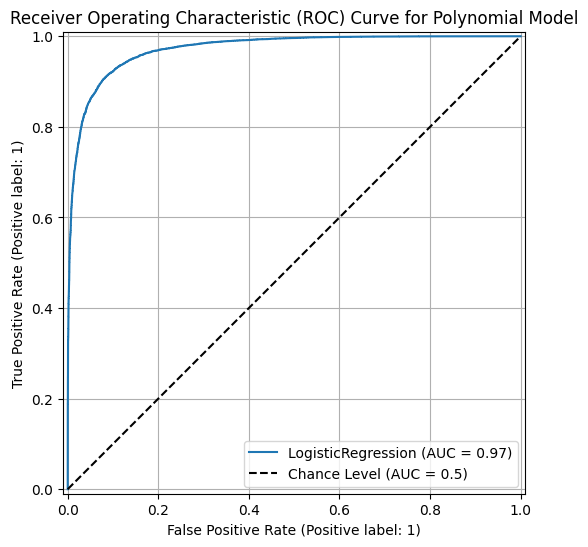

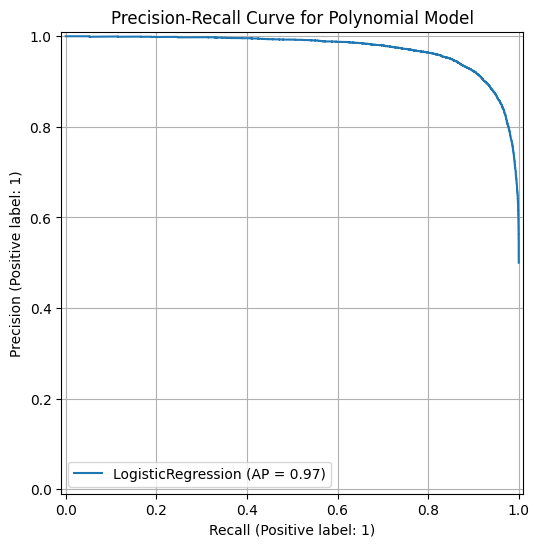

In [98]:
fig_roc1, ax_roc1 = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(polymodel, X_poly_test, y_test_m, ax=ax_roc1)
ax_roc1.set_title('Receiver Operating Characteristic (ROC) Curve for Polynomial Model')
ax_roc1.plot([0, 1], [0, 1], 'k--', label='Chance Level (AUC = 0.5)')
ax_roc1.legend(loc='lower right')
plt.grid(True)
plt.show()

fig_pr1, ax_pr1 = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(polymodel, X_poly_test, y_test_m, ax=ax_pr1)
ax_pr1.set_title('Precision-Recall Curve for Polynomial Model')
plt.grid(True)
plt.show()








Real-data set application.










In [50]:
df = pd.read_csv(data)

display(df.head())

,3.6216,8.6661,-2.8073,-0.44699,0
0,4.54590,8.1674,-2.4586,-1.46210,0
1,3.86600,-2.6383,1.9242,0.10645,0
2,3.45660,9.5228,-4.0112,-3.59440,0
3,0.32924,-4.4552,4.5718,-0.98880,0
4,4.36840,9.6718,-3.9606,-3.16250,0


Scale the data so it is compatible for a PCA transformation.

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Separate features (X) and target (y) from the dataframe
X = df.iloc[:, :-1]  # All columns except the last one are features
y = df.iloc[:, -1]   # The last column is the target (binary categorical)

X_scaled = scaler.fit_transform(X) # Scale only the features

print("Shape of scaled features:", X_scaled.shape)
print("First 5 values of y:")
display(y.head())

Shape of scaled features: (1371, 4)
First 5 values of y:


,0
0,0
1,0
2,0
3,0
4,0


Conduct a PCA transformation of the data into two principle components.

In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['Principle Component 1', 'Principle Component 2'])
pca_df['target'] = y.reset_index(drop=True)

display(pca_df.head())

,Principle Component 1,Principle Component 2,target
0,1.639446,1.096619,0
1,-0.514158,1.325522,0
2,2.311791,0.206376,0
3,-1.192353,-0.024764,0
4,2.319605,0.576206,0


Graph a hued scatterplot of the PCA'd dataset.

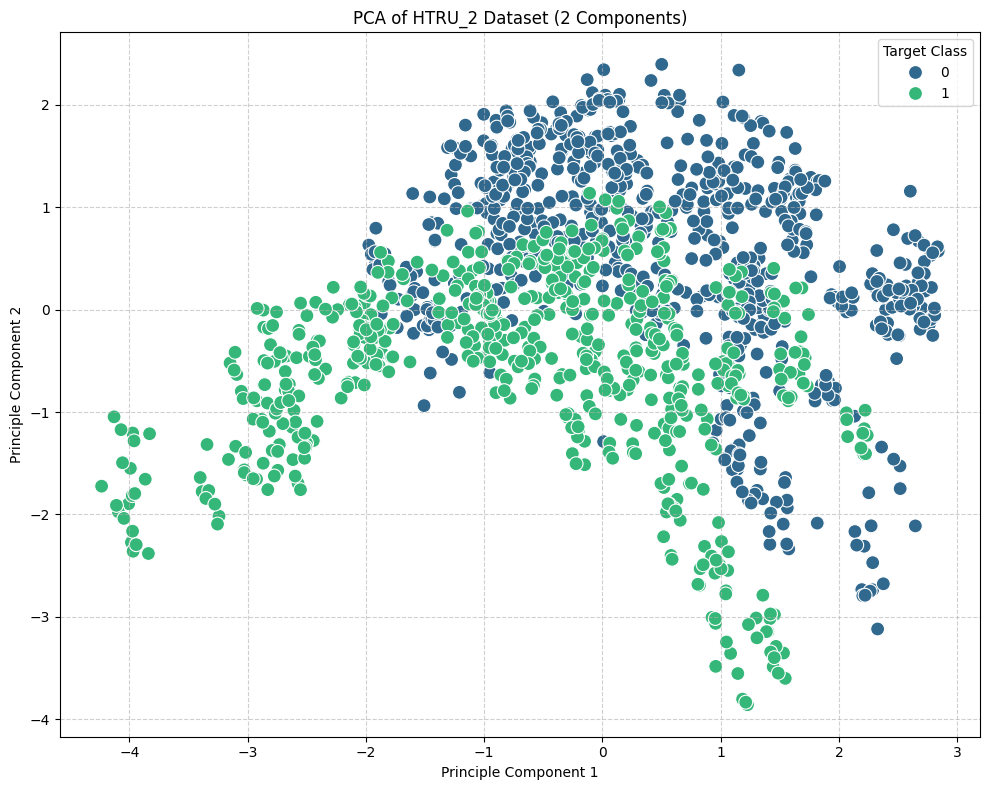

In [53]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='Principle Component 1', y='Principle Component 2', hue='target', palette='viridis', s=100, ax=ax)
plt.title('PCA of HTRU_2 Dataset (2 Components)')
plt.xlabel('Principle Component 1')
plt.ylabel('Principle Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Target Class')
plt.tight_layout()
plt.show()

Create a decision boundary for the PCA data.

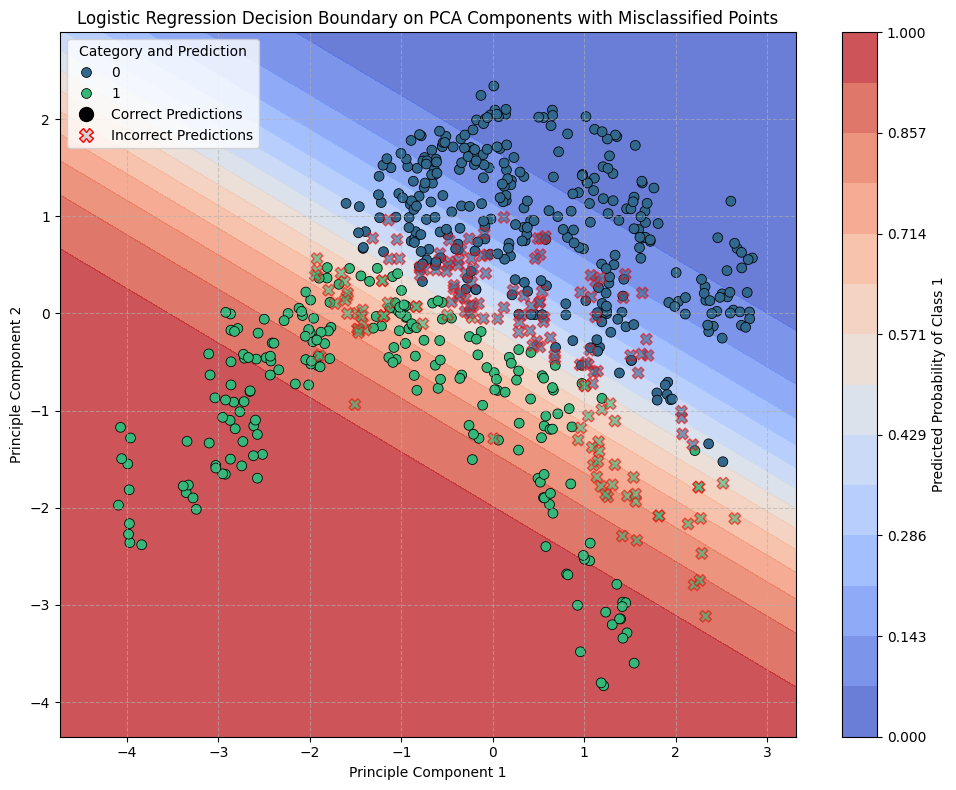

In [102]:
# Graph the decision boundary for the Logistic Regression model on PCA components

x_min_pca, x_max_pca = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min_pca, y_max_pca = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5

h_pca = 0.05  # step size in the mesh
xx_pca, yy_pca = np.meshgrid(np.arange(x_min_pca, x_max_pca, h_pca),
                                 np.arange(y_min_pca, y_max_pca, h_pca))

# Predict probabilities for each point in the meshgrid
meshgrid_data_pca = np.c_[xx_pca.ravel(), yy_pca.ravel()]
Z_pca = model.predict_proba(meshgrid_data_pca)[:, 1]
Z_pca = Z_pca.reshape(xx_pca.shape)

# Create the plot
plt.figure(figsize=(10, 8))

# Plot decision boundary as a contour map
plt.contourf(xx_pca, yy_pca, Z_pca, alpha=0.8, cmap='coolwarm', levels=np.linspace(0, 1, 15))
plt.colorbar(label='Predicted Probability of Class 1')

# Identify correctly and incorrectly predicted instances for the PCA model
# Convert X_test to DataFrame for easier indexing if needed, but here numpy indexing works
correct_predictions_pca = X_test[y_pred == y_test]
incorrect_predictions_pca = X_test[y_pred != y_test]

# Plot correctly predicted instances
sns.scatterplot(
    x=correct_predictions_pca[:, 0],
    y=correct_predictions_pca[:, 1],
    hue=y_test[y_pred == y_test],
    palette='viridis',
    legend='full',
    ax=plt.gca(),
    s=50,
    edgecolor='k'
)

# Plot incorrectly predicted instances in a lighter shade
sns.scatterplot(
    x=incorrect_predictions_pca[:, 0],
    y=incorrect_predictions_pca[:, 1],
    hue=y_test[y_pred != y_test],
    palette='viridis_r',
    legend=False,
    ax=plt.gca(),
    s=70,
    marker='X',
    edgecolor='red',
    linewidth=1,
    alpha=0.6
)

# Add title and labels
plt.title('Logistic Regression Decision Boundary on PCA Components with Misclassified Points')
plt.xlabel('Principle Component 1')
plt.ylabel('Principle Component 2')
plt.grid(True, linestyle='--', alpha=0.6)

# Create custom legend handles for prediction types
from matplotlib.lines import Line2D

handles_pca, labels_pca = plt.gca().get_legend_handles_labels()

correct_pred_handle_pca = Line2D([0], [0], marker='o', color='w', label='Correct Predictions',
                                      markeredgecolor='k', markerfacecolor='k', markersize=10, lw=0)
incorrect_pred_handle_pca = Line2D([0], [0], marker='X', color='w', label='Incorrect Predictions',
                                        markeredgecolor='red', markerfacecolor='lightgrey', markersize=10, lw=0)

final_handles_pca = handles_pca + [correct_pred_handle_pca, incorrect_pred_handle_pca]
final_labels_pca = labels_pca + ['Correct Predictions', 'Incorrect Predictions']

plt.gca().legend(handles=final_handles_pca, labels=final_labels_pca, title='Category and Prediction')

plt.tight_layout()
plt.show()

Evaluate model metrics.

In [56]:
model = LogisticRegression(random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.5, random_state=1)

# Train the logistic regression model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Logistic Regression Model Performance:
Accuracy: 0.7668
Precision: 0.7491
Recall: 0.7043
F1-Score: 0.7260


Find the best polynomial degree for the model and implement it in the new model.

In [86]:
max_num=1
max=0
for i in range(1,11):
  poly = PolynomialFeatures(degree=i)
  X_poly_train1 = poly.fit_transform(X_train)
  X_poly_test1 = poly.transform(X_test)

  polymodel1 = LogisticRegression(random_state=1, max_iter=1000)
  polymodel1.fit(X_poly_train1, y_train)

  y_pred_poly = polymodel1.predict(X_poly_test1)
  f1_poly1 = f1_score(y_test, y_pred_poly, pos_label=1)
  if f1_poly1>max:
    max=f1_poly1
    max_num=i
print(max_num)
poly = PolynomialFeatures(degree=max_num)
X_poly_train1 = poly.fit_transform(X_train)
X_poly_test1 = poly.transform(X_test)

polymodel1 = LogisticRegression(random_state=1, max_iter=1000)
polymodel1.fit(X_poly_train1, y_train)

y_pred_poly = polymodel1.predict(X_poly_test1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

7


Create the (final) decision boundary of the PCA polynomial logisitic regression model.

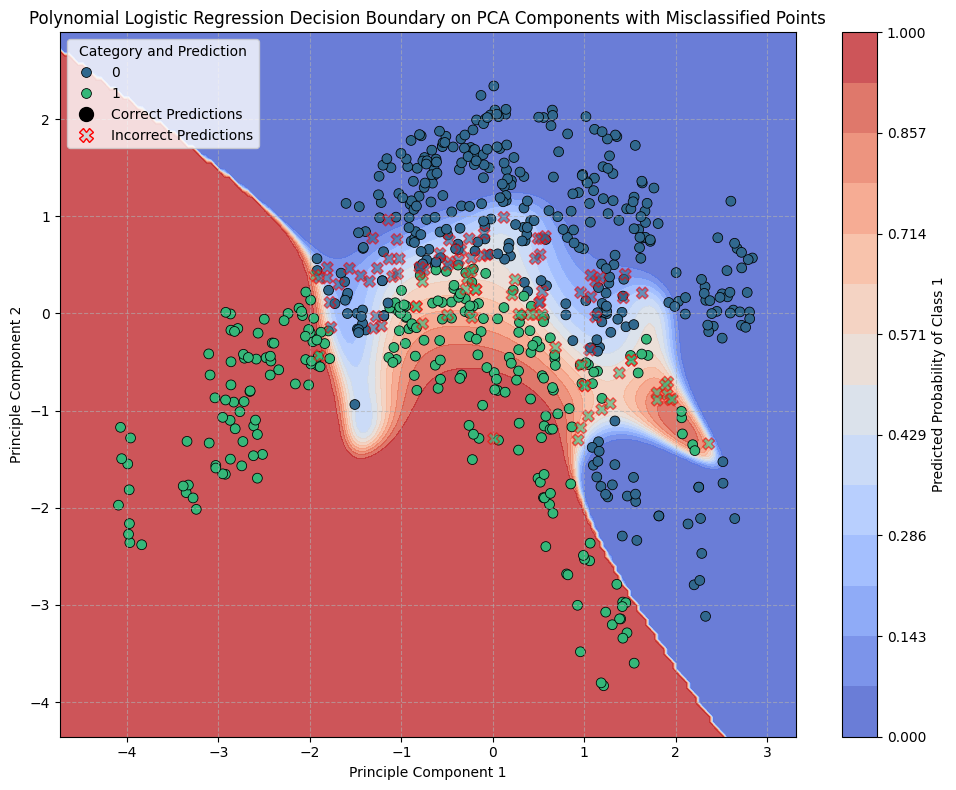

In [87]:
# Graph the decision boundary for the Polynomial Logistic Regression model on PCA components

x_min_poly_pca, x_max_poly_pca = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min_poly_pca, y_max_poly_pca = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5

h_poly_pca = 0.05  # step size in the mesh
xx_poly_pca, yy_poly_pca = np.meshgrid(np.arange(x_min_poly_pca, x_max_poly_pca, h_poly_pca),
                                       np.arange(y_min_poly_pca, y_max_poly_pca, h_poly_pca))

# Transform meshgrid data using the fitted PolynomialFeatures
meshgrid_data_poly_pca = np.c_[xx_poly_pca.ravel(), yy_poly_pca.ravel()]
meshgrid_data_poly_pca_transformed = poly.transform(meshgrid_data_poly_pca)

# Predict probabilities for each point in the transformed meshgrid
Z_poly_pca = polymodel1.predict_proba(meshgrid_data_poly_pca_transformed)[:, 1]
Z_poly_pca = Z_poly_pca.reshape(xx_poly_pca.shape)

# Create the plot
plt.figure(figsize=(10, 8))

# Plot decision boundary as a contour map
plt.contourf(xx_poly_pca, yy_poly_pca, Z_poly_pca, alpha=0.8, cmap='coolwarm', levels=np.linspace(0, 1, 15))
plt.colorbar(label='Predicted Probability of Class 1')

# Identify correctly and incorrectly predicted instances for the polynomial PCA model
correct_predictions_poly_pca = X_test[y_pred_poly == y_test]
incorrect_predictions_poly_pca = X_test[y_pred_poly != y_test]

# Plot correctly predicted instances
sns.scatterplot(
    x=correct_predictions_poly_pca[:, 0],
    y=correct_predictions_poly_pca[:, 1],
    hue=y_test[y_pred_poly == y_test],
    palette='viridis',
    legend='full',
    ax=plt.gca(),
    s=50,
    edgecolor='k'
)

# Plot incorrectly predicted instances in a lighter shade
sns.scatterplot(
    x=incorrect_predictions_poly_pca[:, 0],
    y=incorrect_predictions_poly_pca[:, 1],
    hue=y_test[y_pred_poly != y_test],
    palette='viridis_r',
    legend=False,
    ax=plt.gca(),
    s=70,
    marker='X',
    edgecolor='red',
    linewidth=1,
    alpha=0.6
)

# Add title and labels
plt.title('Polynomial Logistic Regression Decision Boundary on PCA Components with Misclassified Points')
plt.xlabel('Principle Component 1')
plt.ylabel('Principle Component 2')
plt.grid(True, linestyle='--', alpha=0.6)

# Create custom legend handles for prediction types
from matplotlib.lines import Line2D

handles_poly_pca, labels_poly_pca = plt.gca().get_legend_handles_labels()

correct_pred_handle_poly_pca = Line2D([0], [0], marker='o', color='w', label='Correct Predictions',
                                      markeredgecolor='k', markerfacecolor='k', markersize=10, lw=0)
incorrect_pred_handle_poly_pca = Line2D([0], [0], marker='X', color='w', label='Incorrect Predictions',
                                        markeredgecolor='red', markerfacecolor='lightgrey', markersize=10, lw=0)

final_handles_poly_pca = handles_poly_pca + [correct_pred_handle_poly_pca, incorrect_pred_handle_poly_pca]
final_labels_poly_pca = labels_poly_pca + ['Correct Predictions', 'Incorrect Predictions']

plt.gca().legend(handles=final_handles_poly_pca, labels=final_labels_poly_pca, title='Category and Prediction')

plt.tight_layout()
plt.show()

Evaluate metrics and visualizations.

Metrics for the Polynomial Logistic Regression Model on PCA Components:
Precision (Class 1): 0.8616
Recall (Class 1): 0.8272
F1-Score (Class 1): 0.8441


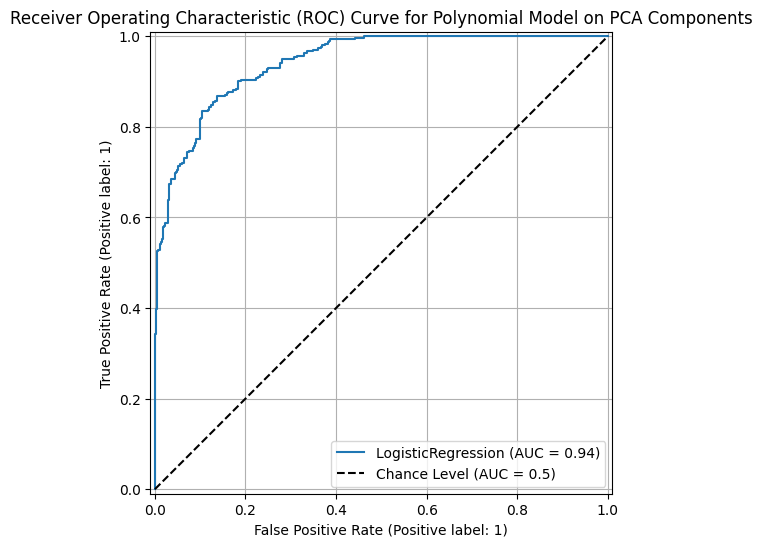

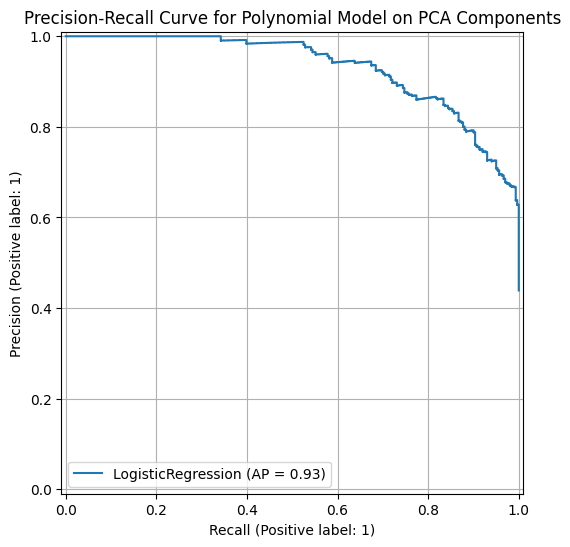

In [101]:
# Get predictions for the polynomial PCA model
y_pred_poly_pca = polymodel1.predict(X_poly_test1)

precision_poly1 = precision_score(y_test, y_pred_poly_pca, pos_label=1)
recall_poly1 = recall_score(y_test, y_pred_poly_pca, pos_label=1)
f1_poly1 = f1_score(y_test, y_pred_poly_pca, pos_label=1)

print(f"Metrics for the Polynomial Logistic Regression Model on PCA Components:")
print(f"Precision (Class 1): {precision_poly1:.4f}")
print(f"Recall (Class 1): {recall_poly1:.4f}")
print(f"F1-Score (Class 1): {f1_poly1:.4f}")

# Get predicted probabilities for ROC and PR curves
y_pred_proba_poly1 = polymodel1.predict_proba(X_poly_test1)[:, 1]

# Add ROC Curve
fig_roc_poly_pca, ax_roc_poly_pca = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(polymodel1, X_poly_test1, y_test, ax=ax_roc_poly_pca)
ax_roc_poly_pca.set_title('Receiver Operating Characteristic (ROC) Curve for Polynomial Model on PCA Components')
ax_roc_poly_pca.plot([0, 1], [0, 1], 'k--', label='Chance Level (AUC = 0.5)')
ax_roc_poly_pca.legend(loc='lower right')
plt.grid(True)
plt.show()

# Add Precision-Recall Curve
fig_pr_poly_pca, ax_pr_poly_pca = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(polymodel1, X_poly_test1, y_test, ax=ax_pr_poly_pca)
ax_pr_poly_pca.set_title('Precision-Recall Curve for Polynomial Model on PCA Components')
plt.grid(True)
plt.show()

Find the equation of the model and define the coefficient values.

In [104]:
import numpy as np

# Get coefficients and intercept from the trained polymodel1
coefficients = polymodel1.coef_[0]
intercept = polymodel1.intercept_[0]

# Get feature names from the PolynomialFeatures object using its internal names
feature_names_raw = poly.get_feature_names_out()

# Replace generic 'x0', 'x1' with 'PC1', 'PC2' for readability
feature_names = [name.replace('x0', 'PC1').replace('x1', 'PC2') for name in feature_names_raw]

# Construct the linear part of the equation (b0 + b1*x1 + ...)
linear_equation_terms = [f"{intercept:.4f}"]
for i, coef in enumerate(coefficients):
    linear_equation_terms.append(f"{coef:.4f}*{feature_names[i]}")

linear_equation = ' + '.join(linear_equation_terms).replace('+ -', '- ')

# Construct the full logistic regression equation
equation = f"P(Y=1) = 1 / (1 + exp(-({linear_equation})))"

print("Equation for PCA Polynomial Logistic Regression Model:")
print(equation)

Equation for PCA Polynomial Logistic Regression Model:
P(Y=1) = 1 / (1 + exp(-(0.8269 + 0.0201*1 - 0.7445*xpos - 2.1453*ypos - 1.2504*xpos^2 + 0.4517*xpos ypos + 1.1320*ypos^2 - 0.8250*xpos^3 - 0.1562*xpos^2 ypos + 0.5985*xpos ypos^2 - 0.0388*ypos^3 + 0.1157*xpos^4 - 0.8126*xpos^3 ypos - 1.0624*xpos^2 ypos^2 + 0.2833*xpos ypos^3 + 0.1663*ypos^4 + 1.0734*xpos^5 + 0.8690*xpos^4 ypos - 0.1054*xpos^3 ypos^2 - 0.0840*xpos^2 ypos^3 + 0.3676*xpos ypos^4 - 0.1207*ypos^5 + 0.0503*xpos^6 + 0.2187*xpos^5 ypos - 0.0089*xpos^4 ypos^2 - 0.7506*xpos^3 ypos^3 - 1.2196*xpos^2 ypos^4 + 0.5794*xpos ypos^5 - 0.1384*ypos^6 - 0.2305*xpos^7 - 0.2539*xpos^6 ypos - 0.2641*xpos^5 ypos^2 - 0.8956*xpos^4 ypos^3 - 0.0264*xpos^3 ypos^4 + 0.6452*xpos^2 ypos^5 - 0.3492*xpos ypos^6 - 0.4919*ypos^7)))
